In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_excel('visitas_foz.xlsx')

In [3]:
df

,Data,Visitas
0,2020-01-01,8342
1,2020-02-01,7761
2,2020-03-01,9175
3,2020-04-01,6823
4,2020-05-01,7541
5,2020-06-01,6074
6,2020-07-01,8876
7,2020-08-01,8034
8,2020-09-01,7530
9,2020-10-01,7389


Gráfico salvo em C:/Users/gabri/Documents/fozzi/graficos\visitas_por_mes.html


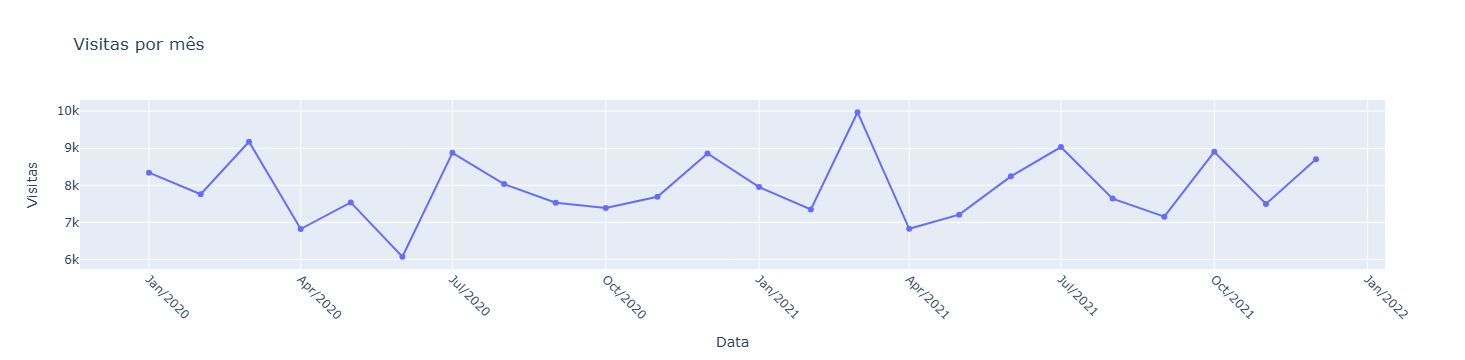

In [16]:

import os
import plotly.express as px
import plotly.io as pio


fig = px.line(df, x='Data', y='Visitas', title='Visitas por mês', markers=True)

fig.update_layout(
    xaxis=dict(
        tickformat="%b/%Y",
        tickangle=45
    )
)

# Defina a pasta onde quer salvar o HTML
pasta = 'C:/Users/gabri/Documents/fozzi/graficos'  # troque para seu caminho desejado

# Cria a pasta caso não exista
os.makedirs(pasta, exist_ok=True)

# Caminho completo do arquivo
caminho_arquivo = os.path.join(pasta, 'visitas_por_mes.html')

# Salvar o gráfico
pio.write_html(fig, caminho_arquivo)

print(f'Gráfico salvo em {caminho_arquivo}')

# Se quiser mostrar o gráfico na tela também
fig.show()

11:54:07 - cmdstanpy - INFO - Chain [1] start processing
11:54:07 - cmdstanpy - INFO - Chain [1] done processing


Gráfico salvo em C:/Users/gabri/Documents/fozzi/graficos\predição.html


C:\Users\gabri\anaconda3\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



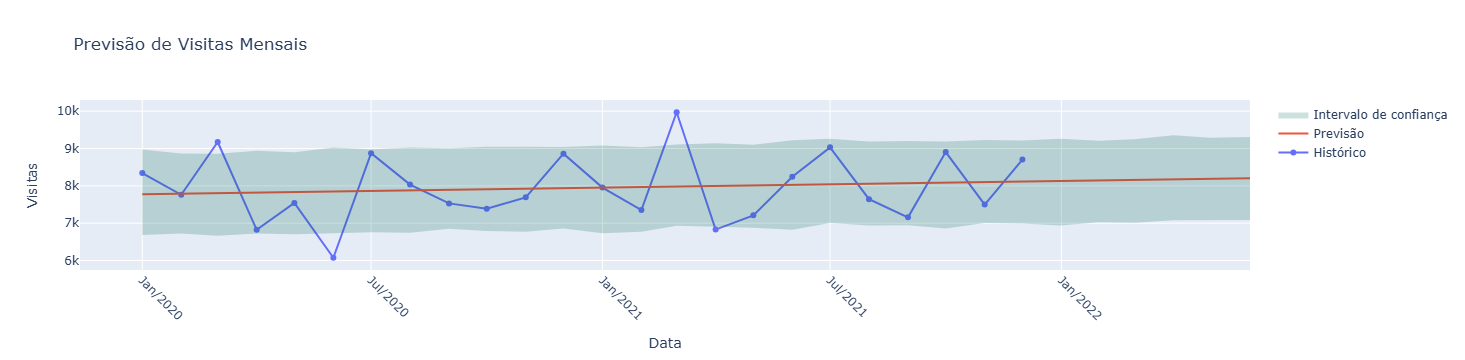

In [20]:
import pandas as pd
from prophet import Prophet
import plotly.graph_objects as go

# Supondo que df já está carregado, com colunas Ano, Mes, Visitas

# 1. Criar coluna 'Data' datetime


# 2. Preparar dados para Prophet: precisa das colunas 'ds' e 'y'
df_prophet = df.rename(columns={'Data': 'ds', 'Visitas': 'y'})[['ds', 'y']]

# 3. Criar e treinar o modelo Prophet
model = Prophet()
model.fit(df_prophet)

# 4. Criar dataframe para datas futuras (6 meses)
future = model.make_future_dataframe(periods=6, freq='M')

# 5. Fazer previsão
forecast = model.predict(future)

# 6. Plotar gráfico com Plotly: histórico + previsão

fig = go.Figure()

# Histórico
fig.add_trace(go.Scatter(
    x=df_prophet['ds'], y=df_prophet['y'],
    mode='markers+lines', name='Histórico'
))

# Previsão
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    mode='lines', name='Previsão'
))

# Intervalo de confiança
fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat_upper'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat_lower'],
    fill='tonexty',
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(0,100,80,0.2)',
    name='Intervalo de confiança'
))

fig.update_layout(
    title='Previsão de Visitas Mensais',
    xaxis_title='Data',
    yaxis_title='Visitas',
    xaxis=dict(tickformat='%b/%Y', tickangle=45)
)

pasta = 'C:/Users/gabri/Documents/fozzi/graficos'  # troque para seu caminho desejado

# Cria a pasta caso não exista
os.makedirs(pasta, exist_ok=True)

# Caminho completo do arquivo
caminho_arquivo = os.path.join(pasta, 'predição.html')

# Salvar o gráfico
pio.write_html(fig, caminho_arquivo)

print(f'Gráfico salvo em {caminho_arquivo}')

# Se quiser mostrar o gráfico na tela também
fig.show()

